# Chapter 6: Simulation of Dynamic Models


> **Source and scope.** This is an original computational companion to Mark M. Meerschaert, *Mathematical Modeling*, 4th ed. (Academic Press, 2013). It follows the chapter structure and reconstructs representative models in Python. It does not reproduce the textbook's prose, figures, or complete exercise sets. Equations, numerical assumptions, and example names are attributed to the book.


This notebook follows Sections 6.1-6.4: discrete simulation, continuous-time simulation, the Euler method, and chaos/fractals.


In [1]:
from __future__ import annotations

import platform
import warnings
from importlib.metadata import version

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scipy
import sympy as sp
from IPython.display import display

warnings.filterwarnings("ignore", category=RuntimeWarning)
np.set_printoptions(precision=6, suppress=True)
pd.set_option("display.precision", 6)
plt.rcParams["figure.figsize"] = (8, 4.8)

SEED = 20260731
rng = np.random.default_rng(SEED)

versions = pd.Series({
    "Python": platform.python_version(),
    "NumPy": np.__version__,
    "SciPy": scipy.__version__,
    "SymPy": sp.__version__,
    "pandas": pd.__version__,
    "Matplotlib": version("matplotlib"),
}, name="version")
display(versions.to_frame())


,version
Python,3.13.5
NumPy,2.3.5
SciPy,1.17.0
SymPy,1.14.0
pandas,2.2.3
Matplotlib,3.10.8


## 6.1 Discrete-time simulation: the battle model

Red starts with five divisions and blue with two. Direct-fire and area-fire attrition are combined in a two-state difference equation. The parameter \(\lambda\) is blue's weapon-effectiveness advantage.


In [2]:
def simulate_battle(lam, red0=5.0, blue0=2.0, a=0.05, b=0.005, max_hours=168):
    red, blue = float(red0), float(blue0)
    history = [(0, red, blue)]
    winner = "draw"
    for hour in range(1, max_hours + 1):
        next_red = red - lam * a * blue - lam * b * red * blue
        next_blue = blue - a * red - b * red * blue
        red, blue = next_red, next_blue
        history.append((hour, red, blue))
        if red <= 0 or blue <= 0:
            if red <= 0 and blue <= 0:
                winner = "simultaneous"
            elif red <= 0:
                winner = "blue"
            else:
                winner = "red"
            break
    return pd.DataFrame(history, columns=["hour", "red", "blue"]), winner

rows = []
for lam in [1, 1.5, 2, 3, 5, 6]:
    history, winner = simulate_battle(lam)
    rows.append({
        "lambda": lam,
        "hours": int(history.hour.iloc[-1]),
        "winner": winner,
        "red remaining": max(0.0, history.red.iloc[-1]),
        "blue remaining": max(0.0, history.blue.iloc[-1]),
    })
display(pd.DataFrame(rows))


,lambda,hours,winner,red remaining,blue remaining
0,1.0,8,red,4.382907,0.000000
1,1.5,9,red,4.060242,0.000000
2,2.0,9,red,3.722475,0.000000
3,3.0,10,red,2.997234,0.000000
4,5.0,17,red,0.963338,0.000000
5,6.0,13,blue,0.000000,0.581079


In [3]:
def blue_wins(lam, red0=5.0, blue0=2.0):
    return simulate_battle(lam, red0=red0, blue0=blue0)[1] == "blue"

def threshold_advantage(red0, blue0=2.0, low=1.0, high=20.0, iterations=60):
    while not blue_wins(high, red0=red0, blue0=blue0):
        high *= 2
    for _ in range(iterations):
        mid = (low + high) / 2
        if blue_wins(mid, red0=red0, blue0=blue0):
            high = mid
        else:
            low = mid
    return high

threshold = threshold_advantage(5.0)
print(f"Continuous search threshold for a blue win: lambda ≈ {threshold:.4f}")
print("Rounded to one decimal place, this agrees with the chapter's lambda_min ≈ 5.4.")

force_rows = []
for red0 in range(2, 9):
    force_rows.append({"red:blue": f"{red0}:2", "lambda_min": threshold_advantage(float(red0))})
force_table = pd.DataFrame(force_rows)
display(force_table)


Continuous search threshold for a blue win: lambda ≈ 5.3130
Rounded to one decimal place, this agrees with the chapter's lambda_min ≈ 5.4.


,red:blue,lambda_min
0,2:2,1.000000
1,3:2,2.125914
2,4:2,3.580637
3,5:2,5.312987
4,6:2,7.280364
5,7:2,9.446780
6,8:2,11.781406


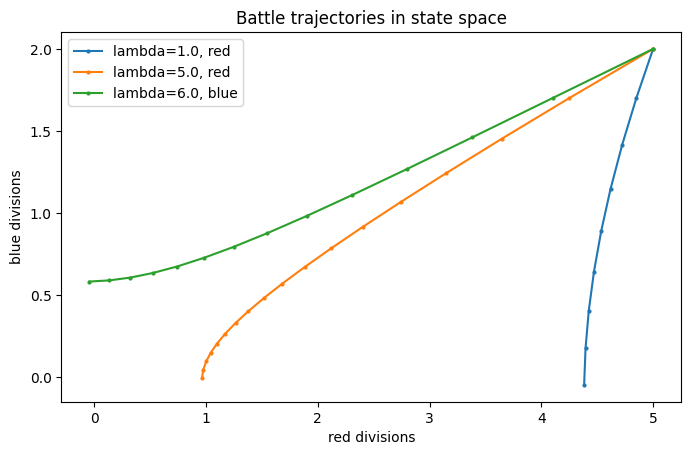

In [4]:
for lam in [1.0, 5.0, 6.0]:
    history, winner = simulate_battle(lam)
    plt.plot(history.red, history.blue, marker="o", markersize=2, label=f"lambda={lam}, {winner}")
plt.xlabel("red divisions")
plt.ylabel("blue divisions")
plt.title("Battle trajectories in state space")
plt.legend()
plt.show()


## 6.2-6.3 Continuous models and the Euler method

Euler's method replaces \(x'=F(x)\) by \(x_{n+1}=x_n+hF(x_n)\). Its global error is first order in \(h\), so halving the step should roughly halve the final-state error.


In [5]:
from scipy.integrate import solve_ivp

def euler(rhs, t0, x0, final_time, steps):
    x0 = np.asarray(x0, dtype=float)
    h = (final_time - t0) / steps
    times = np.linspace(t0, final_time, steps + 1)
    states = np.empty((steps + 1, x0.size), dtype=float)
    states[0] = x0
    for n in range(steps):
        states[n + 1] = states[n] + h * np.asarray(rhs(times[n], states[n]), dtype=float)
    return times, states

def rlc_rhs(time, state):
    i, v = state
    return np.array([i - i**3 - v, i])

reference = solve_ivp(rlc_rhs, (0, 10), [0.1, 0.3], rtol=1e-12, atol=1e-14, dense_output=True, max_step=0.002)
step_counts = np.array([250, 500, 1_000, 2_000, 4_000])
errors = []
for steps in step_counts:
    _, states = euler(rlc_rhs, 0, [0.1, 0.3], 10, int(steps))
    errors.append(np.linalg.norm(states[-1] - reference.y[:, -1]))
errors = np.array(errors)

convergence = pd.DataFrame({
    "steps": step_counts,
    "h": 10 / step_counts,
    "final-state error": errors,
})
display(convergence)

slope = np.polyfit(np.log(10 / step_counts), np.log(errors), 1)[0]
print(f"Estimated convergence order: {slope:.3f}")


,steps,h,final-state error
0,250,0.0400,0.076457
1,500,0.0200,0.038735
2,1000,0.0100,0.019505
3,2000,0.0050,0.009788
4,4000,0.0025,0.004903


Estimated convergence order: 0.991


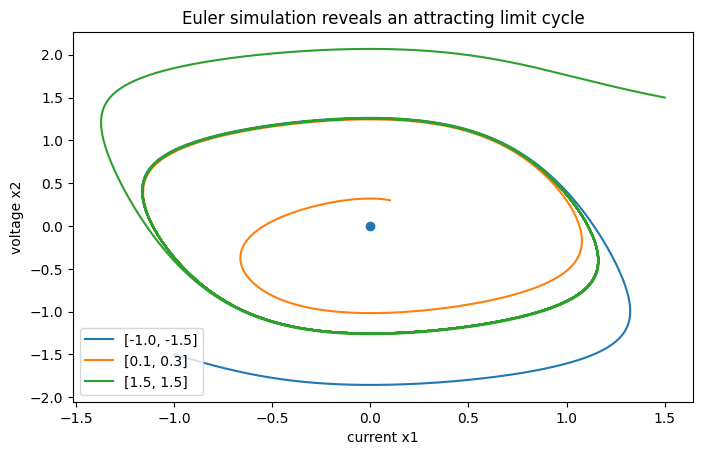

In [6]:
for initial in [[-1.0, -1.5], [0.1, 0.3], [1.5, 1.5]]:
    _, states = euler(rlc_rhs, 0, initial, 40, 20_000)
    plt.plot(states[:, 0], states[:, 1], label=str(initial))
plt.scatter([0], [0], zorder=3)
plt.xlabel("current x1")
plt.ylabel("voltage x2")
plt.title("Euler simulation reveals an attracting limit cycle")
plt.legend()
plt.show()


## 6.4 Time-step-induced bifurcation in the whale model

A large Euler step is not merely less accurate. It creates a different discrete dynamical system. The chapter observes equilibrium, oscillation, period doubling, chaos, and finally divergence as the step grows.


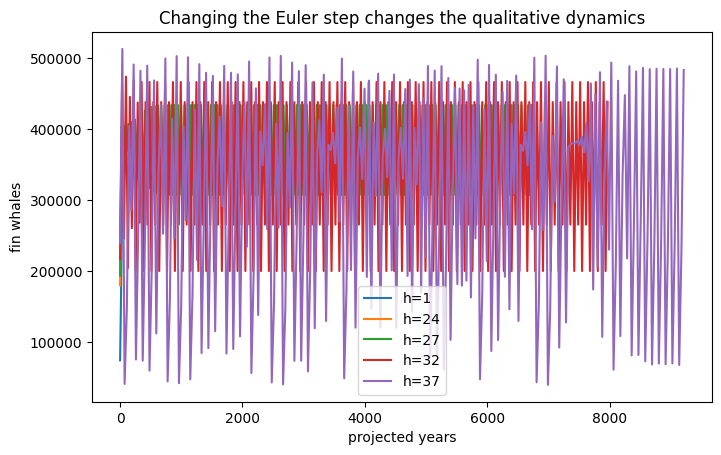

In [7]:
alpha = 1e-7

def whale_rate(state):
    blue, fin = state
    interaction = alpha * blue * fin
    return np.array([
        0.05 * blue * (1 - blue / 150_000) - interaction,
        0.08 * fin * (1 - fin / 400_000) - interaction,
    ])

def whale_euler(step_size, iterations=500, initial=(5_000.0, 70_000.0)):
    state = np.asarray(initial, dtype=float)
    values = []
    for _ in range(iterations):
        state = state + step_size * whale_rate(state)
        if not np.all(np.isfinite(state)) or np.max(np.abs(state)) > 2_000_000:
            break
        values.append(state.copy())
    return np.asarray(values)

for h in [1, 24, 27, 32, 37]:
    trajectory = whale_euler(h, iterations=250)
    plt.plot(np.arange(len(trajectory)) * h, trajectory[:, 1], label=f"h={h}")
plt.xlabel("projected years")
plt.ylabel("fin whales")
plt.title("Changing the Euler step changes the qualitative dynamics")
plt.legend()
plt.show()


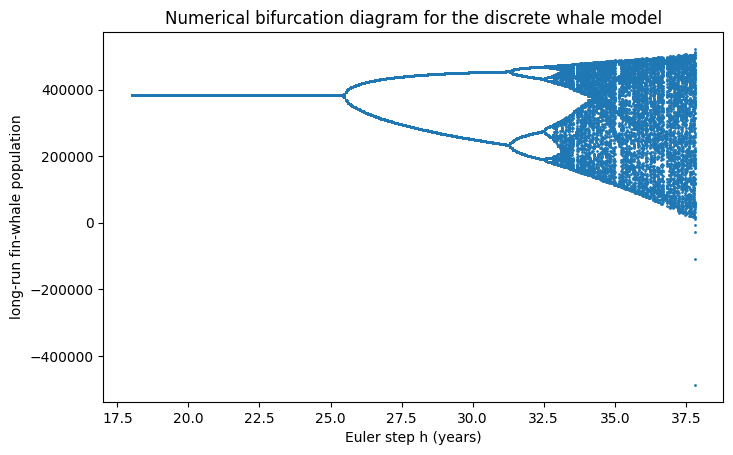

In [8]:
h_values = np.linspace(18, 39, 450)
bifurcation_h = []
bifurcation_fin = []
for h in h_values:
    trajectory = whale_euler(float(h), iterations=700)
    if len(trajectory) >= 150:
        tail = trajectory[-100:, 1]
        bifurcation_h.extend([h] * len(tail))
        bifurcation_fin.extend(tail)

plt.scatter(bifurcation_h, bifurcation_fin, s=1)
plt.xlabel("Euler step h (years)")
plt.ylabel("long-run fin-whale population")
plt.title("Numerical bifurcation diagram for the discrete whale model")
plt.show()


## Lorenz equations and sensitive dependence

The chapter's convection model uses \(\sigma=10\), \(b=8/3\), and a temperature-gradient parameter \(r\). At \(r=28\), trajectories approach a strange attractor and nearby initial states separate rapidly.


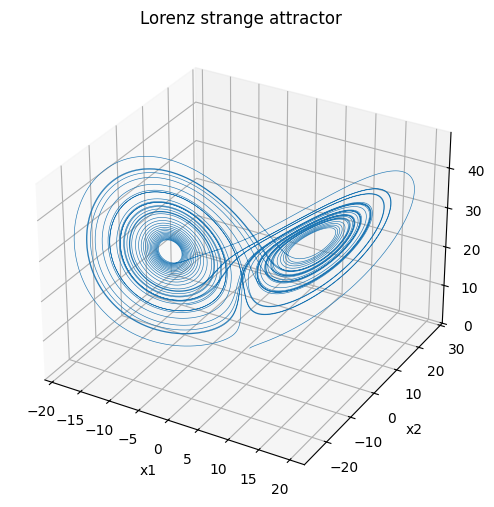

In [9]:
def lorenz(time, state, sigma=10.0, r=28.0, b=8 / 3):
    x, y, z = state
    return [sigma * (y - x), r * x - y - x * z, x * y - b * z]

lorenz_time = np.linspace(0, 45, 18_000)
lorenz_sol = solve_ivp(lorenz, (lorenz_time[0], lorenz_time[-1]), [1, 1, 1], t_eval=lorenz_time, rtol=1e-9, atol=1e-11)

fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection="3d")
ax.plot(lorenz_sol.y[0], lorenz_sol.y[1], lorenz_sol.y[2], linewidth=0.45)
ax.set_xlabel("x1")
ax.set_ylabel("x2")
ax.set_zlabel("x3")
ax.set_title("Lorenz strange attractor")
plt.show()


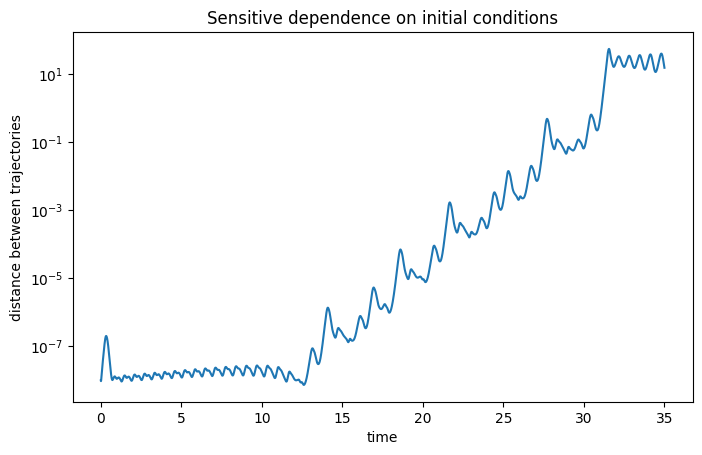

In [10]:
nearby = solve_ivp(lorenz, (0, 35), [1 + 1e-8, 1, 1], t_eval=np.linspace(0, 35, 8_000), rtol=1e-9, atol=1e-11)
base = solve_ivp(lorenz, (0, 35), [1, 1, 1], t_eval=nearby.t, rtol=1e-9, atol=1e-11)
separation = np.linalg.norm(base.y - nearby.y, axis=0)

plt.semilogy(base.t, np.maximum(separation, 1e-16))
plt.xlabel("time")
plt.ylabel("distance between trajectories")
plt.title("Sensitive dependence on initial conditions")
plt.show()


## Chapter checkpoint

Simulation extends the range of solvable models but moves verification into the foreground. Step-size checks are not optional ceremony. They distinguish the intended continuous model from numerical artifacts, some of which are mathematically fascinating and operationally useless.
